In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from path import Path

In [2]:
from matplotlib import style
style.use("dark_background")
np.set_printoptions(linewidth=1200)
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

# Helper Functions

In [3]:
def load_json_artifact(path:str|Path)->dict:
    data_dict = {}
    try:
        with open(path, "r", encoding="utf-8") as file:
            data_dict = json.load(file)
    except:
        print(f"Error Loading file: {path}")
    
    return data_dict

In [4]:
def load_csv_artifact(path:str|Path)->dict:
    data_df = pd.DataFrame()
    try:
        data_df = pd.read_csv(path)
    except:
        print(f"Error Loading file: {path}")
    
    return data_df

---

# Manifest & Output Completness Validation
Inputs:
- manifest_outputs.json
- manifest_run.json

### Load Data

In [5]:
## Load manifest and output artifacts ##
outputs_dict = load_json_artifact("manifest_outputs.json") # "manifest_outputs.json" 
run_dict = load_json_artifact("manifest_run.json") # "manifest_run.json"

print(outputs_dict)
print(run_dict)

{'artifact_count': 27, 'artifacts': [{'artifact_key': 'alignment_coverage_by_work_csv', 'exists': True, 'filename': 'alignment_coverage_by_work.csv', 'modified_at_utc': '2026-06-10T22:37:35.594864+00:00', 'path': '/opt/interlink/kjvDataProj/Code/Interlink_Analytics_Grid/studies/drift/outputs/drift_20260610T223724Z/alignment_coverage_by_work.csv', 'sha256': 'bc20e1fc124193d945e30488d86a0e0cdd402e0598ee64405cb3f0edd26686b9', 'size_bytes': 6342}, {'artifact_key': 'alignment_exceptions_jsonl', 'exists': True, 'filename': 'alignment_exceptions.jsonl', 'modified_at_utc': '2026-06-10T22:37:35.677865+00:00', 'path': '/opt/interlink/kjvDataProj/Code/Interlink_Analytics_Grid/studies/drift/outputs/drift_20260610T223724Z/alignment_exceptions.jsonl', 'sha256': '7ca45e3dad8ef9774cc2fec797f2fdbf9a4814b4585f65b109839b7adca839ee', 'size_bytes': 2504487}, {'artifact_key': 'baseline_gap_indices_by_scope_csv', 'exists': True, 'filename': 'baseline_gap_indices_by_scope.csv', 'modified_at_utc': '2026-06-10T

### Confirm Study Purpose
Notes:
- Study purpose notes should reflect that of a drift study between the KJV 1611 (left) and KJV 1769 (right) Bible canon
- Category labels should only include: 'orthographic_character_form', 'punctuation_clause_relation', 'lexical_substitution', 'function_word_change', 'pronoun_shift', 'negation_modality_change', 'word_order_syntactic_shift', 'addition_deletion', 'multi_factor_complex'

In [6]:
# Validate canon pair chosen
print(f"Canon Pair: {run_dict["config"]["corpus_pair"]["left_canon_id"]} (left) {run_dict["config"]["corpus_pair"]["right_canon_id"]} (right)")

# Confirm Purpose
print(f"Study Purpose: {run_dict["config"]["corpus_pair"]["comparison_name"]}")

# Confirm Category Labels
print(f"Category Labels: {run_dict["config"]["interpretability"]["category_labels"]}")

expected_categories = ['orthographic_character_form', 'punctuation_clause_relation', 'lexical_substitution', 'function_word_change', 'pronoun_shift', 'negation_modality_change', 'word_order_syntactic_shift', 'addition_deletion', 'multi_factor_complex']
category_diff = list(set(run_dict["config"]["interpretability"]["category_labels"]) - set(expected_categories))

print(f"Extra Categories Present In Study: {category_diff}")

Canon Pair: KJV-1611 (left) KJV-1769 (right)
Study Purpose: kjv1611_vs_kjv1769
Category Labels: ['orthographic_character_form', 'punctuation_clause_relation', 'lexical_substitution', 'function_word_change', 'pronoun_shift', 'negation_modality_change', 'word_order_syntactic_shift', 'addition_deletion', 'multi_factor_complex']
Extra Categories Present In Study: []


Notes: Correct canon pair, correct purpose, all categories accounted for and no additional categories present. Purpose and labels are sufficient to proceed.

### Check outputs
Notes:
- "outlier_rankings.csv" will show as missing. This artifact was generated external to the InterLink Analytics Grid due to the logic used to generate the artifact being implemented after the study was ran. "outlier_rankings.csv" is now generated in the threshold_engine.py module and will no longer be generated externally.

In [7]:
expected = [v for k,v in run_dict["config"]["outputs"].items() if k not in ["output_root", "run_name"]]
actual = [k.get("filename") for k in outputs_dict["artifacts"] if k["exists"]]

print(f"Expected Outputs ({outputs_dict["artifact_count"]} artifacts): {expected}")
print(f"Actual Outputs ({outputs_dict["artifacts_existing"]} artifacts): {actual}")
print(f"Missing Outputs ({outputs_dict["artifacts_missing"]} artifacts): {list(set(expected) - set(actual))}")

Expected Outputs (27 artifacts): ['alignment_coverage_by_work.csv', 'alignment_exceptions.jsonl', 'baseline_gap_indices_by_scope.csv', 'canonical_analysis_records.csv', 'canonical_analysis_records.parquet', 'category_annotation_dataset.csv', 'category_counts.csv', 'category_enrichment_results.csv', 'coverage_summary_table.csv', 'drift_indices_by_scope.csv', 'drift_labels_by_unit.csv', 'drift_pairs.csv', 'drift_pairs.parquet', 'exclusive_dataset_inventory.csv', 'inlier_background_annotation.csv', 'interpretability_dataset.csv', 'manifest_outputs.json', 'manifest_run.json', 'null_distribution_summary.csv', 'outlier_rankings.csv', 'scope_registry.csv', 'scope_registry.parquet', 'sensitivity_indices_by_scope.csv', 'statistical_diagnostics_by_scope.csv', 'statistical_test_results.csv', 'threshold_summary_by_scope.csv', 'top_outliers_annotated.csv']
Actual Outputs (26 artifacts): ['alignment_coverage_by_work.csv', 'alignment_exceptions.jsonl', 'baseline_gap_indices_by_scope.csv', 'canonical_

End Note: Expected derived output artifact missing from platform initial run rectified by manual generation derived from threshold assignment row outputs, and feature implemented into patch for InterLink.

### Config Validation
Notes:
- WORK should be Primary with 5000 permutations
- WORK_GROUP should be Secondary with 1000 permutations
- CANON should be Exploratory with 500 permutations
- R0, and R1 should be the active representations
- R2 is disabled for this study

In [8]:
print("Inferential Design:\nNull Scope\t\tRole\t\tPermutations")
print(f"{run_dict["config"]["permutations"]["primary_null_scope"]}\t\t\tPrimary\t\t\t{run_dict["config"]["permutations"]["primary_permutations"]}")
print(f"{run_dict["config"]["permutations"]["secondary_null_scope"]}\t\tSecondary\t\t{run_dict["config"]["permutations"]["minimum_permutations"]}")
print(f"{run_dict["config"]["permutations"]["exploratory_null_scope"]}\t\t\tExploratory\t\t{run_dict["config"]["permutations"]["exploratory_permutations"]}")
print("\n")


print(f"Active Representations: {[k.replace("_used", "").upper() for k,v in run_dict["config"]["representations"].items() if k in ["r0_used", "r1_used", "r2_used"] and v]}")

Inferential Design:
Null Scope		Role		Permutations
WORK			Primary			5000
WORK_GROUP		Secondary		1000
CANON			Exploratory		500


Active Representations: ['R0', 'R1']


End Note: Permutation config is correct, R0 and R1 are active while R2 is disabled. This is satisfactory.

### Section Conclusion
Study manifest and outputs are validated. Foundational configurations are as expected.

---

# Coverage and Canon Validation
Inputs:
- coverage_summary_table.csv
- alignment_coverage_by_work.csv
- exclusive_dataset_inventory.csv

### Load Datasets

In [9]:
coverage_df = load_csv_artifact("coverage_summary_table.csv")
alignment_df = load_csv_artifact("alignment_coverage_by_work.csv")
exclusive_df = load_csv_artifact("exclusive_dataset_inventory.csv")

In [10]:
print(coverage_df.head())
print(alignment_df.head())
print(exclusive_df.head())

       scope_name  works_total  units_total_left  units_total_right  units_structurally_aligned  units_exclusive_left  units_r0_eligible  units_r1_eligible  units_r2_eligible  units_r0_missing  units_r1_missing  units_r2_missing
0      ALL_SHARED           66             31102              31102                       31102                     0              31102              31102                  0                 0                 0             31102
1       NT_SHARED           27              7957               7957                        7957                     0               7957               7957                  0                 0                 0              7957
2       OT_SHARED           39             23145              23145                       23145                     0              23145              23145                  0                 0                 0             23145
3  EXCLUSIVE_LEFT           15              5705                  0                 

### Shared Aligned Canon Validation
Current Study Scopes:
- ALL_SHARED
- OT_SHARED
- NT_SHARED
- EXCLUSIVE_LEFT

Notes:
- ALL_SHARED (expected): 31102 units, 66 works, 31102 aligned units, 31102 R0 Eligible, 31102 R1 Eligible
- OT_SHARED (expected): 23145 units, 39 works, 23145 aligned units, 23145 R0 Eligible, 23145 R1 Eligible
- NT_SHARED (expected): 7957 units, 27 works, 7957 aligned units, 7957 R0 Eligible, 7957 R1 Eligible
- EXCLUSIVE_LEFT (expected): 5705 units, 15 works, 0 aligned units, 0 R0 Eligible, 0 R1 Eligible

In [11]:
print(coverage_df[["scope_name", "works_total", "units_total_left", "units_total_right", "units_structurally_aligned", "units_r0_eligible", "units_r1_eligible"]])

       scope_name  works_total  units_total_left  units_total_right  units_structurally_aligned  units_r0_eligible  units_r1_eligible
0      ALL_SHARED           66             31102              31102                       31102              31102              31102
1       NT_SHARED           27              7957               7957                        7957               7957               7957
2       OT_SHARED           39             23145              23145                       23145              23145              23145
3  EXCLUSIVE_LEFT           15              5705                  0                           0                  0                  0


End Note: Table output is satisfactory.

### Work Level Alignment Validation
Expected:
- Left unit count equals right unit count: TRUE
- Structurally aligned equals left total: TRUE
- Left-only shared units: 0
- Right-only shared units: 0
- R0 missing vectors: 0
- R1 missing vectors: 0

In [12]:
# Left unit count equals right unit count
counts_bool = set((alignment_df["units_total_left"].loc[alignment_df["scope_class"] == "SHARED"] == alignment_df["units_total_right"].loc[alignment_df["scope_class"] == "SHARED"]).tolist())
if len(counts_bool) > 1:
    counts_bool = "FALSE"
counts_bool = "TRUE"
print(f"Left unit count equals right unit count: {counts_bool}")

# Structurally aligned equals left total
counts_bool = set((alignment_df["units_total_left"].loc[alignment_df["scope_class"] == "SHARED"] == alignment_df["units_structurally_aligned"].loc[alignment_df["scope_class"] == "SHARED"]).tolist())
if len(counts_bool) > 1:
    counts_bool = "FALSE"
counts_bool = "TRUE"
print(f"Structurally aligned equals left total: {counts_bool}")

# Left-only shared units: 0
left_only_shared = alignment_df["units_left_only"].loc[alignment_df["scope_class"] == "SHARED"].sum()
print(f"Left-only shared units: {left_only_shared}")

# Right-only shared units: 0
right_only_shared = alignment_df["units_right_only"].loc[alignment_df["scope_class"] == "SHARED"].sum()
print(f"Right-only shared units: {left_only_shared}")

# R0 missing vectors: 0
r0_missing_vec = alignment_df["units_r0_missing_vector"].loc[alignment_df["scope_class"] == "SHARED"].sum()
print(f"R0 missing vectors: {r0_missing_vec}")

# R1 missing vectors: 0
r1_missing_vec = alignment_df["units_r1_missing_vector"].loc[alignment_df["scope_class"] == "SHARED"].sum()
print(f"R1 missing vectors: {r1_missing_vec}")


Left unit count equals right unit count: TRUE
Structurally aligned equals left total: TRUE
Left-only shared units: 0
Right-only shared units: 0
R0 missing vectors: 0
R1 missing vectors: 0


End Note: All aligned units have left and right units for both R0 and R1 representations. This is satisfactory.

### Exclusive Left works Verification
Expected:
- 1Esdras
- 1Maccabees
- 2Esdras
- 2Maccabees
- AdditionstoEsther
- Baruch
- BelandtheDragon
- Judith
- LetterofJeremiah
- PrayerofAzariah
- PrayerofManasseh
- Ecclesiasticus
- Susanna
- Tobit
- WisdomofSolomon

In [13]:
expected = ["1Esdras",
"1Maccabees",
"2Esdras",
"2Maccabees",
"AdditionstoEsther",
"Baruch",
"BelandtheDragon",
"Judith",
"LetterofJeremiah",
"PrayerofAzariah",
"PrayerofManasseh",
"Ecclesiasticus",
"Susanna",
"Tobit",
"WisdomofSolomon"]

actual = alignment_df["work_name"].loc[alignment_df["scope_class"] == "EXCLUSIVE_LEFT"].to_list()

print(actual)
print(f"Expected vs Actual Diff (Exclusive Left): {len(set(expected) - set(actual))}")

['1Esdras', '1Maccabees', '2Esdras', '2Maccabees', 'AdditionstoEsther', 'Baruch', 'BelandtheDragon', 'Judith', 'LetterofJeremiah', 'PrayerofAzariah', 'PrayerofManasseh', 'Ecclesiasticus', 'Susanna', 'Tobit', 'WisdomofSolomon']
Expected vs Actual Diff (Exclusive Left): 0


End Note: All expected works are in the 1611 exclusive corpus with none missing or added. This is satisfactory

### Section Conclusion
66 shared works, 31102 aligned units, 100% R0 & R1 eligibility, and no shared alignment anomalies. 15 left-exclusive works, 5705 units, reserved for future nearest-neighbor analysis. Canon coverage is validated

---

# Drift Results

Inputs:
- drift_indices_by_scope.csv
- sensitivity_indices_by_scope.csv
- drift_pairs.csv

### Load Datasets

In [14]:
drift_indices_df = load_csv_artifact("drift_indices_by_scope.csv")
sens_indicies_df = load_csv_artifact("sensitivity_indices_by_scope.csv")
pairs_df = load_csv_artifact("drift_pairs.csv")

print(drift_indices_df.head())
print(sens_indicies_df.head())
print(pairs_df.head())

   scope_type  scope_name representation      n  median_drift  mad_drift  p95_drift  p99_drift  mean_drift  std_drift  min_drift  max_drift      cssi   tsi_p95   tsi_p99
0       CANON  ALL_SHARED             R0  31102      0.059159   0.031437   0.171811   0.247173    0.070632   0.053336        0.0   0.535045  0.940841  0.828189  0.752827
1       CANON  ALL_SHARED             R1  31102      0.059159   0.031437   0.171811   0.247173    0.070632   0.053336        0.0   0.535045  0.940841  0.828189  0.752827
2  WORK_GROUP   OT_SHARED             R0  23145      0.058865   0.030888   0.170665   0.241909    0.070219   0.052396        0.0   0.503448  0.941135  0.829335  0.758091
3  WORK_GROUP   OT_SHARED             R1  23145      0.058865   0.030888   0.170665   0.241909    0.070219   0.052396        0.0   0.503448  0.941135  0.829335  0.758091
4  WORK_GROUP   NT_SHARED             R0   7957      0.060095   0.032911   0.177303   0.256481    0.071834   0.055962        0.0   0.535045  0.939905 

### Confirm R0 & R1 Equivalence 
#### Ensure equivalence across the shared corpus
From first glance, R0 & R1 findings appear to be exact. This section verifies the observation. If this is the case, R0 & R1 will be reported as a pre processing invariance finding rather than as independent representational evidence in the paper and R0 will be the representation target reported in the paper.

Expected:
- Aligned drift pairs: 31102
- R0 eligible: 31102
- R1 eligible: 31102
- drift_r0 == drift_r1: 31102
- Max abs(drift_r0 - drift_r1): 0.0
- delta_value mean: 0.0
- delta_value median: 0.0
- delta_value max: 0.0

In [15]:
print(f"Aligned drift pairs: {pairs_df.shape[0]}")
print(f"R0 eligible: {pairs_df["eligible_r0"].loc[pairs_df["eligible_r0"] == True].count()}")
print(f"R1 eligible: {pairs_df["eligible_r1"].loc[pairs_df["eligible_r1"] == True].count()}")
print(f"drift_r0 == drift_r1: {(pairs_df["drift_r0"] == pairs_df["drift_r1"]).sum()}")
print(f"Max abs(drift_r0 - drift_r1): {(pairs_df["drift_r0"] - pairs_df["drift_r1"]).abs().max()}")
print(f"delta_value mean: {pairs_df["delta_value"].mean()}")
print(f"delta_value median: {pairs_df["delta_value"].median()}")
print(f"delta_value max: {pairs_df["delta_value"].max()}")


Aligned drift pairs: 31102
R0 eligible: 31102
R1 eligible: 31102
drift_r0 == drift_r1: 31102
Max abs(drift_r0 - drift_r1): 0.0
delta_value mean: 0.0
delta_value median: 0.0
delta_value max: 0.0


End Note: R0 & R1 representaions are equivalent. Under mxbai-embed-large, raw text and lightly normalized text produced identical semantic distance estimates for this study. R0/R1 should therefore be reported as a preprocessing invariance finding rather than as independent representational evidence.

### Canon level Drift Profile
This is exploratory analysis for the canon level ALL_SHARED scope level

In [16]:
col_dict = {"scope_type":"Scope", "median_drift":"Median Drift", "mean_drift":"Mean Drift", "p95_drift":"P95", "p99_drift":"P99", "max_drift":"Max", "cssi":"CSSI"}
print(f"{drift_indices_df[["scope_type","n", "median_drift", "mean_drift", "p95_drift", "p99_drift", "max_drift", "cssi"]].loc[drift_indices_df["scope_type"] == "CANON"].loc[drift_indices_df["scope_name"] == "ALL_SHARED"].loc[drift_indices_df["representation"] == "R0"].rename(columns=col_dict).to_string(index=False)}")

Scope     n  Median Drift  Mean Drift      P95      P99      Max     CSSI
CANON 31102      0.059159    0.070632 0.171811 0.247173 0.535045 0.940841


End Note: This supports a high level claim of semantic stability with a measurable tail of higher drift units. The median drift is low, while the maximum and upper percentiles show that a small subset of verses diverges more strongly.

### OT vs NT Drift Profile

In [17]:
col_dict = {"scope_name":"Scope", "median_drift":"Median Drift", "mean_drift":"Mean Drift", "p95_drift":"P95", "p99_drift":"P99", "max_drift":"Max", "cssi":"CSSI"}
print(f"{drift_indices_df[["scope_name","n", "median_drift", "mean_drift", "p95_drift", "p99_drift", "max_drift", "cssi"]].loc[drift_indices_df["scope_name"].isin(["OT_SHARED","NT_SHARED"])].loc[drift_indices_df["scope_type"] == "WORK_GROUP"].loc[drift_indices_df["representation"] == "R0"].rename(columns=col_dict).to_string(index=False)}")

    Scope     n  Median Drift  Mean Drift      P95      P99      Max     CSSI
OT_SHARED 23145      0.058865    0.070219 0.170665 0.241909 0.503448 0.941135
NT_SHARED  7957      0.060095    0.071834 0.177303 0.256481 0.535045 0.939905


End Note: The OT and NT are very close, but the NT has a slightly higher median, P95, P99, and max drift. The Old and New Testament shared corpora exhibited broadly similar semantic stability profiles, with the New Testament showing a slightly heavier upper tail. 

### Zero Drift and Identical Text Units
Table to see the number of drift_r0 units == 0 (i.e., units were the same in KJV 1611 and KJV 1769 canon), number of text_raw_left == text_raw_right (i.e., raw text was the same in KJV 1611 and KJV 1769 canon), number of text_norm_left == text_norm_right (i.e., lightly normalized text was the same in KJV 1611 and KJV 1769 canon), number of unit_checksum_left == unit_checksum_right (i.e., hashed text was the same in KJV 1611 and KJV 1769 canon).

In [18]:
print("Check\t\t\t\t\t\tCount\t\tShare")
print(f"drift_r0 units == 0: \t\t\t\t{pairs_df["drift_r0"].loc[pairs_df["drift_r0"] == 0.0].count()}\t\t{round((pairs_df["drift_r0"] == 0.0).mean()*100, 2)}%")
print(f"text_raw_left == text_raw_right: \t\t{(pairs_df["text_raw_left"] == pairs_df["text_raw_right"]).sum()}\t\t{round((pairs_df["text_raw_left"] == pairs_df["text_raw_right"]).mean()*100, 2)}%")
print(f"text_norm_left == text_norm_right: \t\t{(pairs_df["text_norm_left"] == pairs_df["text_norm_right"]).sum()}\t\t{round((pairs_df["text_norm_left"] == pairs_df["text_norm_right"]).mean()*100, 2)}%")
print(f"unit_checksum_left == unit_checksum_right: \t{(pairs_df["unit_checksum_left"] == pairs_df["unit_checksum_right"]).sum()}\t\t{round((pairs_df["unit_checksum_left"] == pairs_df["unit_checksum_right"]).mean()*100, 2)}%")


Check						Count		Share
drift_r0 units == 0: 				411		1.32%
text_raw_left == text_raw_right: 		411		1.32%
text_norm_left == text_norm_right: 		531		1.71%
unit_checksum_left == unit_checksum_right: 	411		1.32%


End Note: This confirms that zero drift corresponds exactly to the raw text identity in this study run. There are also some additional rows where normalized text is identical even though raw text differs, which is expected for this study as the only differences between the raw text and normalized text is capitalization or similar light form changes. 

### Highest Individual Drift Unit Examples
This shows the Top 10 drift units using representation R0.

In [19]:
print("TOP 10 HIGHEST DRIFT UNITS\n--------------------------")
print(f"{(pairs_df[["unit_key", "work_name", "drift_r0"]].nlargest(10, "drift_r0")).rename(columns={"unit_key":"Unit", "work_name":"Work", "drift_r0":"Drift"}).to_string(index=False)}")

TOP 10 HIGHEST DRIFT UNITS
--------------------------
     Unit           Work    Drift
MRK:14:17           Mark 0.535045
 1TH:5:16 1Thessalonians 0.512382
LEV:11:15      Leviticus 0.503448
MAT:27:14        Matthew 0.495040
DEU:14:14    Deuteronomy 0.491773
  2TI:3:7       2Timothy 0.466832
 LUK:19:1           Luke 0.465284
 JHN:2:13           John 0.430758
  LAM:5:8   Lamentations 0.419692
1CH:23:27    1Chronicles 0.411999


End Note: These will be candidates to discuss under H2 and H3, especially because many involve spelling/orthographic modernization, punctuation relation, or compact wording differences.

### Highest Median Drift Works
This shows the top 10 work level median drift values using representation R0.

In [20]:
work_name_key = pairs_df[["work_code", "work_name"]].drop_duplicates()
work_name_key = dict(zip(work_name_key["work_code"], work_name_key["work_name"]))


print("TOP 10 HIGHEST DRIFT WORKS\n--------------------------")
print(f"{drift_indices_df[["n","scope_name", "median_drift", "p99_drift", "max_drift"]].loc[drift_indices_df["scope_type"] == "WORK"].loc[drift_indices_df["representation"] == "R0"].nlargest(10,"median_drift").assign(scope_name=drift_indices_df["scope_name"].map(lambda x: work_name_key.get(x,x))).to_string(index=False)}")

TOP 10 HIGHEST DRIFT WORKS
--------------------------
  n   scope_name  median_drift  p99_drift  max_drift
 48        Jonah      0.100187   0.271208   0.287811
 13        2John      0.091795   0.257265   0.266562
942  1Chronicles      0.081929   0.256884   0.411999
105        1John      0.080743   0.217794   0.281348
695      2Samuel      0.078027   0.262806   0.329932
 21      Obadiah      0.075614   0.190184   0.192408
 55      Malachi      0.075161   0.228559   0.265509
222 Ecclesiastes      0.071509   0.246293   0.265872
 38       Haggai      0.070460   0.161833   0.171619
280         Ezra      0.069848   0.264361   0.353177


End Note: Jonah and 2 John have a small n. Larger works will be used as examples as they are more stable to discuss.

### R0 Drift Distribution


#### Unit level R0 drift values distribution with median, P95, and P99 markers

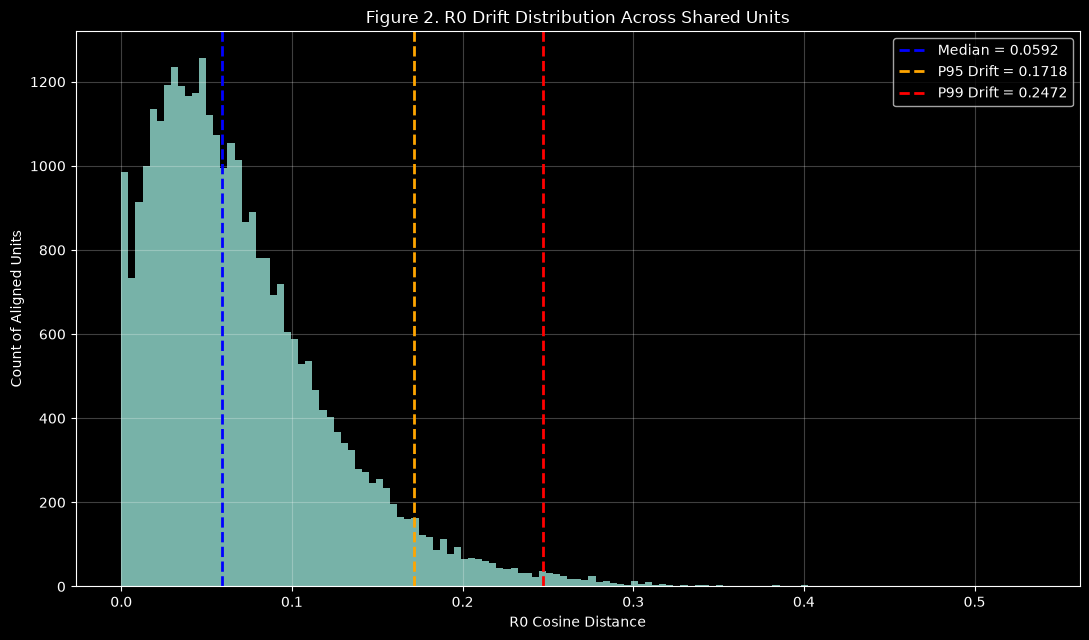

In [21]:
r0_values = pairs_df["drift_r0"].dropna().astype(float)
canon_r0 = drift_indices_df[(drift_indices_df["scope_type"] == "CANON") & (drift_indices_df["scope_name"] == "ALL_SHARED") & (drift_indices_df["representation"] == "R0")].iloc[0]
bin_edges = np.histogram_bin_edges(r0_values, bins="fd")

median_drift = float(canon_r0["median_drift"])
p95_drift = float(canon_r0["p95_drift"])
p99_drift = float(canon_r0["p99_drift"])

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(r0_values, bins=bin_edges, alpha=0.85)
ax.axvline(median_drift, linestyle="--", linewidth=2, label=f"Median = {median_drift:.4f}", color="blue")
ax.axvline(p95_drift, linestyle="--", linewidth=2, label=f"P95 Drift = {p95_drift:.4f}", color="orange")
ax.axvline(p99_drift, linestyle="--", linewidth=2, label=f"P99 Drift = {p99_drift:.4f}", color="red")

ax.set_title("Figure 2. R0 Drift Distribution Across Shared Units")
ax.set_xlabel("R0 Cosine Distance")
ax.set_ylabel("Count of Aligned Units")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)

fig.tight_layout()
plt.show()

#### Work level median drift variation for R0

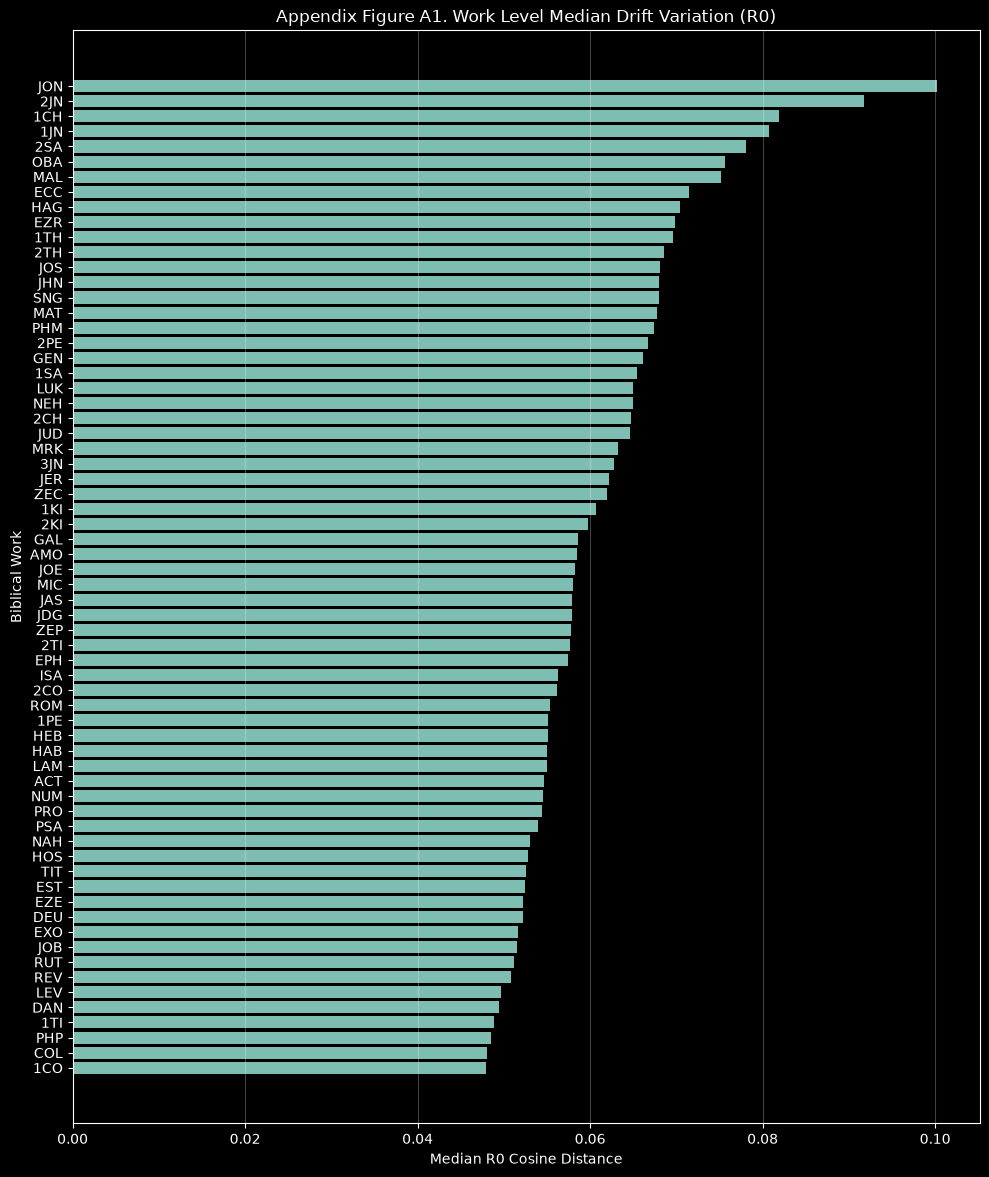

In [22]:
%matplotlib inline
work_r0 = drift_indices_df[(drift_indices_df["scope_type"] == "WORK") & (drift_indices_df["representation"] == "R0")].copy() # filter
work_r0 = work_r0.sort_values("median_drift", ascending=True) # sort

fig_height = max(10, 0.18*len(work_r0)) # dynamic height adjustment
fig,ax = plt.subplots(figsize=(10, fig_height))

ax.barh(work_r0["scope_name"], work_r0["median_drift"], alpha=0.9)
ax.set_title("Appendix Figure A1. Work Level Median Drift Variation (R0)")
ax.set_xlabel("Median R0 Cosine Distance")
ax.set_ylabel("Biblical Work")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

### Section Conclusion
"sensitivity_indices_by_scope.csv" is disregarded as R0 and R1 have been confirmed to be equivalent. These drift outputs support three important claims for the paper:

1. The shared KJV 1611 and KJV 1769 corpus is semantically stable overall with low median drift and high CSSI
2. A small bounded upper tail exists which supports the need for outlier and interpretability analysis
3. R0 and R1 equivalence is a valid preprocessing invariance finding, showing that the mxbai-embed-large embedding model collapses the light normalization difference used in this study.

---

# Threshold and Outlier Results

### Load Datasets

Inputs:
- threshold_summary_by_scope.csv
- drift_labels_by_unit.csv
- outlier_rankings.csv

In [23]:
threshold_df = load_csv_artifact("threshold_summary_by_scope.csv")
drift_labels_df = load_csv_artifact("drift_labels_by_unit.csv")
outlier_rankings_df = load_csv_artifact("outlier_rankings.csv")

print(threshold_df.head())
print(drift_labels_df.head())
print(outlier_rankings_df.head())

   scope_type  scope_name representation      n  median_drift  mad_drift  p95_drift  p99_drift  threshold_primary  threshold_secondary threshold_source  small_sample_flag  mad_zero_flag percentile_method
0       CANON  ALL_SHARED             R0  31102      0.059159   0.031437   0.171811   0.247173           0.247173             0.171811            CANON              False          False         HF_TYPE_7
1       CANON  ALL_SHARED             R1  31102      0.059159   0.031437   0.171811   0.247173           0.247173             0.171811            CANON              False          False         HF_TYPE_7
2  WORK_GROUP   OT_SHARED             R0  23145      0.058865   0.030888   0.170665   0.241909           0.241909             0.170665       WORK_GROUP              False          False         HF_TYPE_7
3  WORK_GROUP   OT_SHARED             R1  23145      0.058865   0.030888   0.170665   0.241909           0.241909             0.170665       WORK_GROUP              False          Fals

### Classification Totals

In [24]:
print("Totals:\nClassification\t\tR0 Rows\t\tR1 Rows\t\tTotal Representation Rows\t\tUnique Units")
print(f"INLIER\t\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "INLIER"].loc[drift_labels_df["representation"] == "R0"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "INLIER"].loc[drift_labels_df["representation"] == "R1"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "INLIER"].count()}\t\t\t\t\t{drift_labels_df["unit_key"].loc[drift_labels_df["classification"] == "INLIER"].nunique()}")
print(f"REVIEW_CANDIDATE\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].loc[drift_labels_df["representation"] == "R0"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].loc[drift_labels_df["representation"] == "R1"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].count()}\t\t\t\t\t{drift_labels_df["unit_key"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].nunique()}")
print(f"STRONG_OUTLIER\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].loc[drift_labels_df["representation"] == "R0"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].loc[drift_labels_df["representation"] == "R1"].count()}\t\t{drift_labels_df["representation"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].count()}\t\t\t\t\t{drift_labels_df["unit_key"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].nunique()}")


print("\nPer Representation:\nClassification\t\tShare")
print(f"INLIER\t\t\t{round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "INLIER"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)}%")
print(f"REVIEW_CANDIDATE\t{round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)}%")
print(f"STRONG_OUTLIER\t\t{round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)}%")
print(f"Total Flagged\t\t{round((drift_labels_df["classification"].loc[drift_labels_df["classification"].isin(["REVIEW_CANDIDATE", "STRONG_OUTLIER"])].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)}%")

Totals:
Classification		R0 Rows		R1 Rows		Total Representation Rows		Unique Units
INLIER			29505		29505		59010					29505
REVIEW_CANDIDATE	1238		1238		2476					1238
STRONG_OUTLIER		359		359		718					359

Per Representation:
Classification		Share
INLIER			94.87%
REVIEW_CANDIDATE	3.98%
STRONG_OUTLIER		1.15%
Total Flagged		5.13%


End Note: Majority of corpus are classified as inliers. Small bounded tail exists consisting ot review candidates and outliers.

### Visualize Threshold Classification Composition
Proportional composition of threshold classifications in R0 layer

[Text(0, 3, '29,505\n(94.87%)'),
 Text(0, 3, '1,238\n(3.98%)'),
 Text(0, 3, '359\n(1.15%)')]

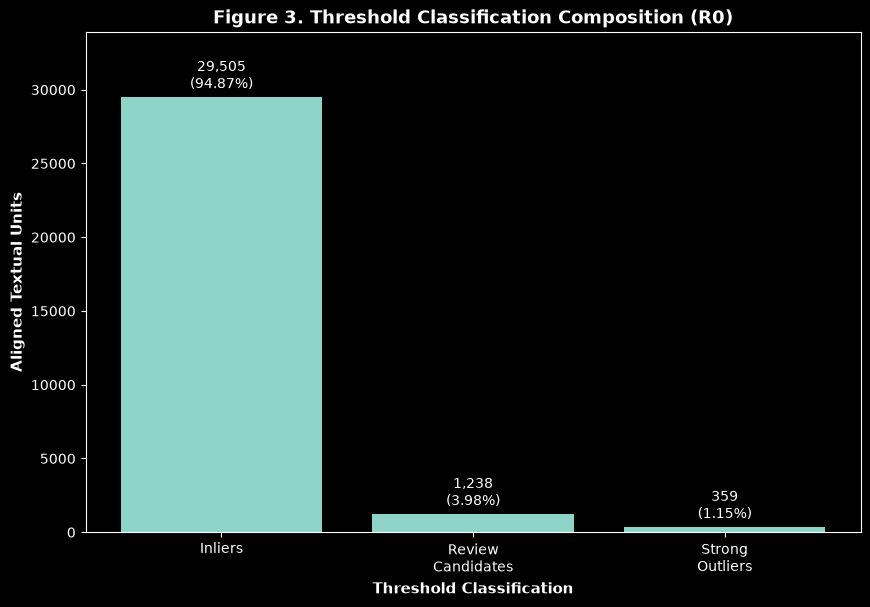

In [25]:
inlier_portion = round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "INLIER"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)
inlier_count = drift_labels_df["classification"].loc[drift_labels_df["classification"] == "INLIER"].loc[drift_labels_df["representation"] == "R0"].count()
review_portion = round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)
review_count = drift_labels_df["classification"].loc[drift_labels_df["classification"] == "REVIEW_CANDIDATE"].loc[drift_labels_df["representation"] == "R0"].count()
outlier_portion = round((drift_labels_df["classification"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].loc[drift_labels_df["representation"] == "R0"].count() / drift_labels_df.loc[drift_labels_df["representation"] == "R0"].shape[0])*100, 2)
outlier_count = drift_labels_df["classification"].loc[drift_labels_df["classification"] == "STRONG_OUTLIER"].loc[drift_labels_df["representation"] == "R0"].count()

counts = [inlier_count, review_count, outlier_count]
labels = ["Inliers", "Review\nCandidates", "Strong\nOutliers"]

fig, ax = plt.subplots(figsize=(10,6.5))

bar = ax.bar(labels, counts)

ax.set_xlabel("Threshold Classification", fontsize=11, fontweight="bold")
ax.set_ylabel("Aligned Textual Units", fontsize=11, fontweight="bold")
ax.set_title("Figure 3. Threshold Classification Composition (R0)", fontsize=13, fontweight="bold")
ax.margins(y=0.15)

ax.bar_label(bar, padding=3,labels=[f"{inlier_count:,}\n({inlier_portion}%)", f"{review_count:,}\n({review_portion}%)", f"{outlier_count:,}\n({outlier_portion}%)"])

End Note: These results indicate the threshold system is selective enough that the classification of "outlier" is a tail phenomennon and not a broad label applied to too much of the corpus. Thresholds are stable.

### Threshold Source (unit level)
Ideally thresholds assigned to text_unit drift pairs should only have a threshold source of "WORK" as the study is designed to apply thresholds with the following precedence: work-level > work_group-level > canon-level if there are multiple thresholds available for the verse pair.

In [26]:
print("Unique Threshold Sources with Row counts:\n-----------------------------------------")
print(f"{drift_labels_df["threshold_source"].value_counts().reset_index(name="Num Rows").to_string(index=False)}")

Unique Threshold Sources with Row counts:
-----------------------------------------
threshold_source  Num Rows
            WORK     62204


End Note: This confirms all unit level classifications are work local, and not driven by broader work group or canon level thresholds. This is desirable for H2 as it avoids labeling a verse as an outlier because its book has a naturally higher or lower drift distribution in comparison to the work group (OT/NT) or canon levels.

### Small Sample Behavior
Review the unit threshold assignments for small sample threshold rows and MAD == 0 rows. This is done at the overall level and flagged outlier level.

In [27]:
print("Works with Small sample flag == True:")
print(f"{threshold_df["scope_name"].loc[threshold_df["scope_type"] == "WORK"].loc[threshold_df["small_sample_flag"]].to_list()}")


print("\n\nAll")
print("Flag\t\t\t\tRow Count\n-----------------------------------------")
print(f"small_sample_flag = True\t{(drift_labels_df["small_sample_flag"]).sum()}")
print(f"small_sample_flag = False\t{(~(drift_labels_df["small_sample_flag"])).sum()}")
print(f"mad_zero_flag = True\t\t{(drift_labels_df["mad_zero_flag"]).sum()}")


print("\n\nFlagged Outlier Rows")
print("Flag\t\t\t\tRow Count\n-----------------------------------------")
print(f"small_sample_flag = True\t{(outlier_rankings_df["small_sample_flag"]).sum()}")
print(f"small_sample_flag = False\t{(~(outlier_rankings_df["small_sample_flag"])).sum()}")


Works with Small sample flag == True:
['2JN', '2JN', '2TH', '2TH', '3JN', '3JN', 'HAG', 'HAG', 'JON', 'JON', 'JUD', 'JUD', 'NAH', 'NAH', 'OBA', 'OBA', 'PHM', 'PHM', 'TIT', 'TIT']


All
Flag				Row Count
-----------------------------------------
small_sample_flag = True	648
small_sample_flag = False	61556
mad_zero_flag = True		0


Flagged Outlier Rows
Flag				Row Count
-----------------------------------------
small_sample_flag = True	66
small_sample_flag = False	3128


End Note: This indicates small sample thresholds are present but do not dominate results. Additionally, there were no MAD zero threshold issues. This is satisfactory.

### Strongest Outliers
Top unique STRONG_OUTLIER units by drift using R0

In [28]:
col_dict = {"rank_within_classification": "Rank", "unit_key":"Unit", "work_name":"Work", "drift_value":"Drift", "threshold_primary": "Primary Threshold", "excess_over_primary":"Excess Over Primary"}

print(f"{outlier_rankings_df[["rank_within_classification", "unit_key", "work_name", "drift_value", "threshold_primary", "excess_over_primary"]].loc[outlier_rankings_df["classification"] == "STRONG_OUTLIER"].loc[outlier_rankings_df["representation"] == "R0"].nlargest(10,"drift_value").rename(columns=col_dict).to_string(index=False)}")

 Rank      Unit           Work    Drift  Primary Threshold  Excess Over Primary
    1 MRK:14:17           Mark 0.535045           0.248540             0.286506
    2  1TH:5:16 1Thessalonians 0.512382           0.311459             0.200923
    3 LEV:11:15      Leviticus 0.503448           0.253694             0.249754
    4 MAT:27:14        Matthew 0.495040           0.257492             0.237548
    5 DEU:14:14    Deuteronomy 0.491773           0.227774             0.263999
    6   2TI:3:7       2Timothy 0.466832           0.229013             0.237819
    7  LUK:19:1           Luke 0.465284           0.242575             0.222709
    8  JHN:2:13           John 0.430758           0.279919             0.150839
    9   LAM:5:8   Lamentations 0.419692           0.293854             0.125838
   10 1CH:23:27    1Chronicles 0.411999           0.256884             0.155115


End Note: These are good H2 candidates as they substantially exceed their work level primary thresholds.

### Works with the most flagged units using R0

In [29]:
tmp_df = outlier_rankings_df[["work_code","work_name"]].loc[outlier_rankings_df["representation"] == "R0"].value_counts().head(10).reset_index(name="flagged_units").rename(columns={"work_code":"scope_name"})
tmp_df= pd.merge(tmp_df, threshold_df[["scope_name", "n"]].loc[threshold_df["representation"] == "R0"], on="scope_name", how="inner")
tmp_df["flagged_units_ratio"] = round((tmp_df["flagged_units"] / tmp_df["n"])*100, 2)
tmp_df = tmp_df.drop(columns=["scope_name", "n"])
print("Top works by unique flagged units\n------------------------------------------------")
print(f"{tmp_df.rename(columns={"work_name":"Work", "flagged_units":"Flagged Units", "flagged_units_ratio": "Ratio"}).to_string(index=False)}")

Top works by unique flagged units
------------------------------------------------
    Work  Flagged Units  Ratio
  Psalms            124   5.04
 Genesis             77   5.02
Jeremiah             69   5.06
  Isaiah             65   5.03
 Numbers             65   5.05
 Ezekiel             64   5.03
  Exodus             61   5.03
    Luke             58   5.04
 Matthew             54   5.04
     Job             54   5.05


End Note: Raw flagged counts wil be skewed based on the size of the work, the ratio will be used for reporting as larger works have more opportunity to produce flagged rows. Appears the top 10 highest flagged works each have a saturation rate of around 5% of flagged units.

### Section Conclusion
Most aligned KJV-1611 & KJV-1769 units exhibit low semantic drift, but work-level thresholds identify a small upper tail subset of review candidates and strong outliers. The outliers provide the emperical basis for targeted interpretability and HITL annotation.

---

# Permutation and Statistical Results (H1)
Aligned KJV-1611 & KJV-1769 units should have substantially lower semantic distance than the randomized baseline parings.

### Load Datasets

Inputs:
- null_distribution_summary.csv
- baseline_gap_indices_by_scope.csv
- statistical_test_results.csv
- statistical_diagnostics_by_scope.csv 

In [30]:
null_dist_df = load_csv_artifact("null_distribution_summary.csv")
baseline_gap_df = load_csv_artifact("baseline_gap_indices_by_scope.csv")
stat_test_df = load_csv_artifact("statistical_test_results.csv")
stat_diag_df = load_csv_artifact("statistical_diagnostics_by_scope.csv")

print(null_dist_df.head())
print(baseline_gap_df.head())
print(stat_test_df.head())
print(stat_diag_df.head())

  representation null_model scope_type scope_name  n_observed  iterations_used  observed_median  null_median  null_mean  null_std  null_min  null_max  p_value_perm
0             R0       WORK       WORK        1CH         942             5000         0.081929     0.450281   0.450270  0.002964  0.439843  0.459977        0.0002
1             R0       WORK       WORK        1CO         437             5000         0.047924     0.495050   0.494946  0.004205  0.478788  0.509070        0.0002
2             R0       WORK       WORK        1JN         105             5000         0.080743     0.419803   0.419738  0.008721  0.388095  0.446545        0.0002
3             R0       WORK       WORK        1KI         816             5000         0.060707     0.469190   0.469164  0.003407  0.453953  0.481439        0.0002
4             R0       WORK       WORK        1PE         105             5000         0.055117     0.432295   0.432537  0.007565  0.405977  0.461194        0.0002
  representation

### Validate Permutation Design
This is for the null model produced in the pipeline. The WORK null model is the primary with 5000 iterations, WORK_GROUP is secondary with 1000 iterations, and CANON is exploratory with 500 iterations. Works with an n < 20 should be excluded from inference.

In [31]:
print("Works to be excluded from inference (H1):\n----------------------------------------")
tmp_df = threshold_df[["scope_name", "n"]].loc[threshold_df["n"] < 20].loc[threshold_df["representation"] == "R0"].loc[threshold_df["scope_type"] == "WORK"]
print(f"{tmp_df.rename(columns={"scope_name": "Work"}).to_string(index=False)}")


exlcude_list = tmp_df["scope_name"].to_list()
if not null_dist_df["scope_name"].isin(exlcude_list).any():
    print("All works that should be excluded are not present in the inference dataset. Proceed.")
else:
    print("Works that should be excluded are present in the inference dataset. Halt Study.")


Works to be excluded from inference (H1):
----------------------------------------
Work  n
 2JN 13
 3JN 14
All works that should be excluded are not present in the inference dataset. Proceed.


End Note: There are 2 books that should be excluded, 2 John and 3 John, thus the total works should be 64 for each active representation R0 and R1.

In [32]:
print("Null Model\t\t\tRole\t\t\tIterations Used\t\t\tRows")
print(f"WORK\t\t\t\tPrimary\t\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "WORK"].unique()}\t\t\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "WORK"].count()}")
print(f"WORK_GROUP\t\t\tSecondary\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "WORK_GROUP"].unique()}\t\t\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "WORK_GROUP"].count()}")
print(f"CANON\t\t\t\tExploratory\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "CANON"].unique()}\t\t\t\t{null_dist_df["iterations_used"].loc[null_dist_df["scope_type"] == "CANON"].count()}")

Null Model			Role			Iterations Used			Rows
WORK				Primary			[5000]				128
WORK_GROUP			Secondary		[1000]				4
CANON				Exploratory		[500]				2


End Note: This is to be expected. 64 work pairs * 2 active representations = 128 WORK null model rows in the inference dataset. 2 work group pairs * 2 active representations = 4 WORK_GROUP null model rows in the inference dataset. 1 canon pair * 2 active representations = 2 CANON null model rows in the inference dataset. All tests passed.

### Explore all tested scopes
Compare baseline and null model pair metrics:
- Observed Median < Null Median
- SGI > 0
- FDR Adjusted permutation p-value < 0.05

In [33]:
print("Check\t\t\t\t\t\tResult\n----------------------------------------------------------------------")
print(f"Observed Median < Null Median\t\t\t{(stat_test_df["observed_median"] < stat_test_df["null_median"]).sum()} / {stat_test_df.shape[0]}")
print(f"SGI > 0\t\t\t\t\t\t{(stat_test_df["sgi"] > 0).sum()} / {stat_test_df.shape[0]}")
print(f"FDR Adjusted permutation p-value < 0.05\t\t{(stat_test_df["p_value_fdr"] < 0.05).sum()} / {stat_test_df.shape[0]}")

Check						Result
----------------------------------------------------------------------
Observed Median < Null Median			134 / 134
SGI > 0						134 / 134
FDR Adjusted permutation p-value < 0.05		134 / 134


End Note: This shows all observed baseline units are semantically more stable than the null randomized baseline. This will support H1 without fault as all test are as expected.

### Primary WORK scope Null Baseline Comparison Results
This is an overall look at WORKs

In [34]:
print("Metric\t\t\t\t\t\tResult\n----------------------------------------------------------------------")
print(f"Tests \t\t\t\t\t\t{(stat_test_df["scope_type"] =="WORK").sum()}")
print(f"Iterations Each \t\t\t\t{", ".join(stat_test_df["iterations_used"].loc[stat_test_df["scope_type"] =="WORK"].unique().astype(str))}")
print(f"Permutation p-value \t\t\t\t{", ".join(stat_test_df["p_value_perm"].loc[stat_test_df["scope_type"] =="WORK"].unique().astype(str))} for all")
print(f"FDR Adjusted p-value\t\t\t\tabout {round(stat_test_df["p_value_fdr"].loc[stat_test_df["scope_type"] =="WORK"].mean(), 6)} for all")
print(f"Median SGI\t\t\t\t\tabout {round(stat_test_df["sgi"].loc[stat_test_df["scope_type"] =="WORK"].median(), 6)}")
print(f"Mean SGI\t\t\t\t\tabout {round(stat_test_df["sgi"].loc[stat_test_df["scope_type"] =="WORK"].mean(), 6)}")
print(f"Median Normalized SGI\t\t\t\tabout {round(stat_test_df["sgi_norm"].loc[stat_test_df["scope_type"] =="WORK"].median(), 6)}")
print(f"Mean Normalized SGI\t\t\t\tabout {round(stat_test_df["sgi_norm"].loc[stat_test_df["scope_type"] =="WORK"].mean(), 6)}")

Metric						Result
----------------------------------------------------------------------
Tests 						128
Iterations Each 				5000
Permutation p-value 				0.0001999600079984 for all
FDR Adjusted p-value				about 0.000209 for all
Median SGI					about 0.40965
Mean SGI					about 0.409133
Median Normalized SGI				about 0.874174
Mean Normalized SGI				about 0.870027


End Note: This is the primary inferential result. Within each work, true aligned verse pairs are far closer semantically than randomized verse pairse from the same work. Lowest possible p-value is 1 / 5001 = 0.00019996

### Secondary WORK_GROUP Null Baseline Comparison Results
This is for the OT & NT work_group null comparison.

In [35]:
col_dict = {"scope_name": "Scope", "n_observed": "n", "observed_median": "Observed Median", "null_median":"Null Median", "sgi": "SGI", "sgi_norm":"Normalized SGI", "p_value_perm":"p-value"}
print(f"{stat_test_df[["representation","scope_name", "n_observed", "observed_median", "null_median", "sgi", "sgi_norm", "p_value_perm"]].loc[stat_test_df["scope_type"] == "WORK_GROUP"].loc[stat_test_df["scope_name"] == "OT_SHARED"].rename(columns=col_dict).to_string(index=False)}")
print('\n')
print(f"{stat_test_df[["representation","scope_name", "n_observed", "observed_median", "null_median", "sgi", "sgi_norm", "p_value_perm"]].loc[stat_test_df["scope_type"] == "WORK_GROUP"].loc[stat_test_df["scope_name"] == "NT_SHARED"].rename(columns=col_dict).to_string(index=False)}")

representation     Scope     n  Observed Median  Null Median      SGI  Normalized SGI  p-value
            R0 OT_SHARED 23145         0.058865     0.503906 0.445041        0.883182 0.000999
            R1 OT_SHARED 23145         0.058865     0.503907 0.445042        0.883182 0.000999


representation     Scope    n  Observed Median  Null Median      SGI  Normalized SGI  p-value
            R0 NT_SHARED 7957         0.060095     0.500734 0.440640        0.879987 0.000999
            R1 NT_SHARED 7957         0.060095     0.500619 0.440524        0.879959 0.000999


End Note: R0 & R1 are nearly identical as expected. The stability result remains strong when aligned units are compared against randomized candidates from the same major corpus division. Lowest possible p-value reported 1 / 1001 = 0.000999

### Exploratory CANON Null Baseline Comparison Results
This is for the canon level null comparison

In [36]:
print(f"{stat_test_df[["representation","scope_name", "n_observed", "observed_median", "null_median", "sgi", "sgi_norm", "p_value_perm"]].loc[stat_test_df["scope_type"] == "CANON"].rename(columns=col_dict).to_string(index=False)}")

representation      Scope     n  Observed Median  Null Median      SGI  Normalized SGI  p-value
            R0 ALL_SHARED 31102         0.059159     0.508390 0.449231        0.883635 0.001996
            R1 ALL_SHARED 31102         0.059159     0.508383 0.449225        0.883634 0.001996


End Note: CANON is exploratory and configured for 500 permutations, the minimum possible p-value is 1 / 501 = 0.001966. The results are as strong as this scope test can report. Results show under the broadest randomized canon level baseline, true aligned pairs are substantially closer than randomized alternatives.

### Secondary Diagnostic Tests
- Mann-Whitney U
- Kolmogorov-Smirnov Test (KS) Test
- Cliff's Delta
- Diagnostic Null Sample Size

In [37]:
alpha = 0.05
mann_str = ""
ks_str = ""
cliff_str = ""


# Interpret Mann-Whitney U p-values
if((stat_diag_df["mwu_p"].max() < alpha) & (stat_diag_df["mwu_p"].min() < alpha)):
    mann_str = "Strongly significant, observed distances are lower than null sample."
elif ((stat_diag_df["mwu_p"].max() > alpha) & stat_diag_df["mwu_p"].min() < alpha):
    if(stat_diag_df["mwu_p"].mean() > alpha):
        if(stat_diag_df["mwu_p"].median() < alpha):
            mann_str = "Moderate significance, most observed distances are lower than the null sample, but some observed samples are higher than the null sample."
        else:
            mann_str = "Low significance, most observed distances are higher than the null sample, with few observed samples being lower than the null sample."
    else:
        if(stat_diag_df["mwu_p"].median() < alpha):
            mann_str = "Moderate significance, most observed distances are lower than the null sample, but some observed samples are higher than the null sample."
        else:
            mann_str = "Low significance, most observed distances are higher than the null sample, with few observed samples being lower than the null sample."
else:
    mann_str = "No significance, observed distances are higher than the null sample."


# Interpret KS test p-values
if((stat_diag_df["ks_p"].max() < alpha) & (stat_diag_df["ks_p"].min() < alpha)):
    ks_str = "Strong distributional separation."
elif ((stat_diag_df["ks_p"].max() > alpha) & stat_diag_df["ks_p"].min() < alpha):
    if(stat_diag_df["ks_p"].mean() > alpha):
        if(stat_diag_df["ks_p"].median() < alpha):
            ks_str = "Moderate distributional separation."
        else:
            ks_str = "Low distributional separation."
    else:
        if(stat_diag_df["ks_p"].median() < alpha):
            ks_str = "Moderate distributional separation."
        else:
            ks_str = "Low distributional separation."
else:
    ks_str = "No distributional separation."


# Interpret Cliff-Delta for all 
cliffs_unique_interp = [x for x in stat_diag_df["cliffs_delta_interpretation"].tolist()]
num_rows = len(cliffs_unique_interp)
cliffs_unique_interp = {item: cliffs_unique_interp.count(item) for item in set(cliffs_unique_interp)}
cliff_str = f"Most Tests Report ({cliffs_unique_interp[max(cliffs_unique_interp, key=cliffs_unique_interp.get)]}/{str(num_rows)}): {max(cliffs_unique_interp, key=cliffs_unique_interp.get)}"



print("Diagnostic\t\t\tn_Null\t\t\tPattern")
print(f"Mann-Whitney U\t\t\t{stat_diag_df["n_null"].unique()}\t\t{mann_str}")
print(f"KS Test\t\t\t\t{stat_diag_df["n_null"].unique()}\t\t{ks_str}")
print(f"Cliff's Delta\t\t\t{stat_diag_df["n_null"].unique()}\t\t{cliff_str}")

Diagnostic			n_Null			Pattern
Mann-Whitney U			[100000]		Strongly significant, observed distances are lower than null sample.
KS Test				[100000]		Strong distributional separation.
Cliff's Delta			[100000]		Most Tests Report (134/134): large; observed_lower_than_null


End Note: These secondary diagnostics tests show the whole observed aligned distance distribution to be overwhelmingly shifted below the randomized null distribution.

### Visualize Drift Medians of Baseline vs Null Groups (Work Level)

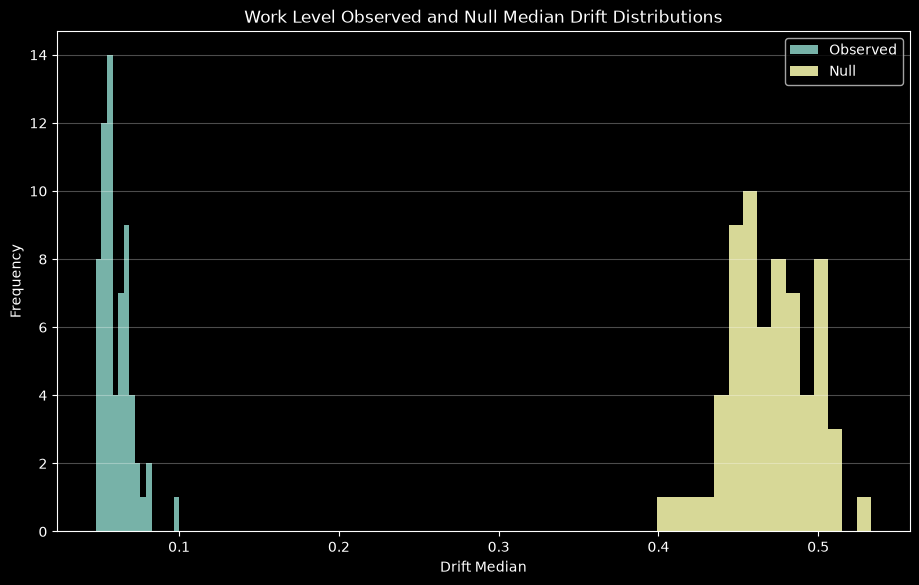

In [38]:
%matplotlib inline

plt.figure(figsize=(11,6.5))

observed_vals = baseline_gap_df["median_observed"].loc[baseline_gap_df["representation"] == "R0"].loc[baseline_gap_df["null_model"] == "WORK"].loc[baseline_gap_df["scope_type"] == "WORK"]
null_vals = baseline_gap_df["median_null"].loc[baseline_gap_df["representation"] == "R0"].loc[baseline_gap_df["null_model"] == "WORK"].loc[baseline_gap_df["scope_type"] == "WORK"]

plt.hist(observed_vals, bins=15, alpha=0.85, label="Observed")
plt.hist(null_vals, bins=15, alpha=0.85, label="Null")


plt.title("Work Level Observed and Null Median Drift Distributions")
plt.xlabel("Drift Median")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

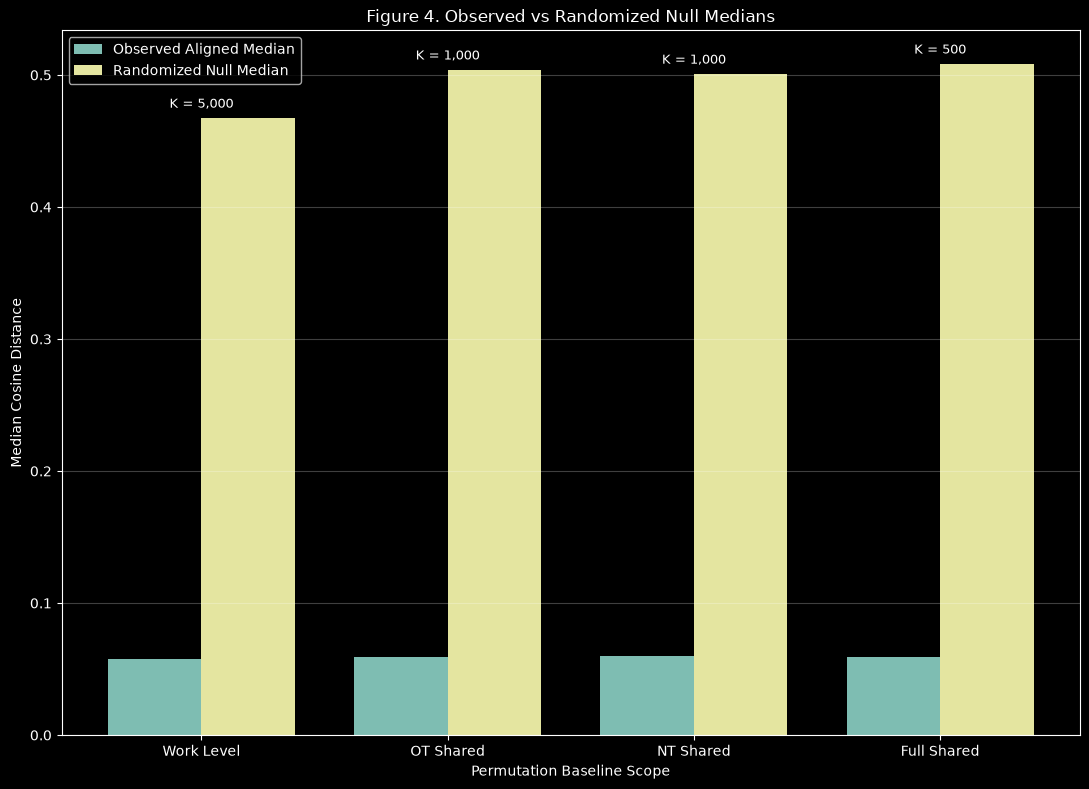

In [39]:
r0_null = null_dist_df[null_dist_df["representation"] == "R0"].copy()
work_rows = r0_null[(r0_null["null_model"] == "WORK") & (r0_null["scope_type"] == "WORK")] # aggregate work level tests

work_summary = {"scope_label": "Work Level", "observed_median": work_rows["observed_median"].median(), "null_median":work_rows["null_median"].median(), "iterations_used":int(work_rows["iterations_used"].max())}
scope_rows = r0_null[((r0_null["null_model"] == "WORK_GROUP") & (r0_null["scope_type"] == "WORK_GROUP") & (r0_null["scope_name"].isin(["OT_SHARED", "NT_SHARED"]))) | 
                     ((r0_null["null_model"] == "CANON") & (r0_null["scope_type"] == "CANON") & (r0_null["scope_name"] == "ALL_SHARED"))].copy() # division of workgroup and canon scopes

label_map = {"OT_SHARED": "OT Shared", "NT_SHARED": "NT Shared", "ALL_SHARED": "Full Shared"}
scope_rows["scope_label"] = scope_rows["scope_name"].map(label_map)

plot_df = pd.concat([pd.DataFrame([work_summary]), scope_rows[["scope_label", "observed_median", "null_median", "iterations_used"]]], ignore_index=True)

# order display
order = ["Work Level", "OT Shared", "NT Shared", "Full Shared"]
plot_df["scope_label"] = pd.Categorical(plot_df["scope_label"], categories=order, ordered=True)
plot_df = plot_df.sort_values("scope_label")

x = range(len(plot_df))
width = 0.38

fig,ax = plt.subplots(figsize=(11,8))

observed_pos = [i - width / 2 for i in x]
null_pos = [i + width / 2 for i in x]

bar1 = ax.bar(observed_pos, plot_df["observed_median"], width=width, label="Observed Aligned Median", alpha=0.9)
bar2 = ax.bar(null_pos, plot_df["null_median"], width=width, label="Randomized Null Median", alpha=0.9)

ax.set_title("Figure 4. Observed vs Randomized Null Medians")
ax.set_xlabel("Permutation Baseline Scope")
ax.set_ylabel("Median Cosine Distance")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["scope_label"])
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=True)


# Add iteration Count note above grouped pairs
for i, row in enumerate(plot_df.itertuples(index=False)):
    y = max(row.observed_median, row.null_median)
    ax.text(i, y+0.015, f"K = {row.iterations_used:,}", ha="center", va="top", fontsize=9)
    

fig.tight_layout()
plt.show()

### Section Conclusion
The permutation and statistical artifacts strongly support H1. Accross work level, work-group level, and exploratory canon level baselines, true KJV-1611 and KJV-1769 aligned text units exhibit lower semantic distance than randomized pairings. This supports the conclusion that the two editions are highly semantically stable at the aligned unit level, while preserving enough upper tail variation to justify outlier and category analysis.

---

# HITL Category Enrichment / Overrepresentation Analysis
Because R0 and R1 are drift equivalent, category finding will not be treated as two independent annotation experiments. For the paper R0 will be the representative annotation layer

### Load Datasets

Inputs:
- category_counts.csv
- category_enrichment_results.csv
- category_annotation_dataset.csv
- top_outliers_annotated.csv
- interpretability_dataset.csv

In [40]:
counts_df = load_csv_artifact("category_counts.csv")
enrichment_res_df = load_csv_artifact("category_enrichment_results.csv")
annotation_df = load_csv_artifact("category_annotation_dataset.csv")
top_outliers_df = load_csv_artifact("top_outliers_annotated.csv")
interpretability_df = load_csv_artifact("interpretability_dataset.csv")

print(counts_df.head())
print("\n")
print(enrichment_res_df.head())
print("\n")
print(annotation_df.head())


  representation outlier_set                     category  count_flagged_with_category  count_flagged_total  count_background_with_category  count_background_total
0             R0     FLAGGED  orthographic_character_form                         1597                 1597                             519                     526
1             R0     FLAGGED  punctuation_clause_relation                          229                 1597                              82                     526
2             R0     FLAGGED         lexical_substitution                          182                 1597                              83                     526
3             R0     FLAGGED         function_word_change                            2                 1597                               1                     526
4             R0     FLAGGED                pronoun_shift                            1                 1597                               0                     526


  representati

In [41]:
print(top_outliers_df.head())
print("\n")
print(interpretability_df.head())

    unit_key work_code  division_level_1  division_level_2  drift_r0  drift_r1  drift_r2 delta_representation_left delta_representation_right  delta_value                                      text_raw_left                                     text_raw_right                                     text_norm_left                                    text_norm_right  drift_label_r0  drift_label_r1  drift_label_r2             residual_class                             character_diff_summary                                 token_diff_summary                                phrase_diff_summary  category_labels
0  MRK:14:17       MRK                14                17  0.535045  0.535045       NaN                        R0                         R1          0.0    And in the euening hee commeth with the twelue.      And in the evening he cometh with the twelve.    and in the euening hee commeth with the twelue.      and in the evening he cometh with the twelve.  STRONG_OUTLIER  STRONG_OUTLIER      

### HITL Annotation Coverage
This show what the annotation dataset contains.

In [42]:
print("Group\t\t\tRepresentation Rows\t\t\tUnique Units")
print(f"FLAGGED\t\t\t\t{(annotation_df["annotation_set"] == "FLAGGED").sum()}\t\t\t\t{annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "FLAGGED"].nunique()}")
print(f"INLIER_BACKGROUND\t\t{(annotation_df["annotation_set"] == "INLIER_BACKGROUND").sum()}\t\t\t\t{annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "INLIER_BACKGROUND"].nunique()}")

print(f"\nNum FLAGGED rows unlabeled: {(annotation_df["category_labels"].loc[annotation_df["annotation_set"] == "FLAGGED"].isna()).sum()}")
print(f"Num INLIER_BACKGROUND rows unlabeled: {(annotation_df["category_labels"].loc[annotation_df["annotation_set"] == "INLIER_BACKGROUND"].isna()).sum()}")

Group			Representation Rows			Unique Units
FLAGGED				3194				1597
INLIER_BACKGROUND		1052				526

Num FLAGGED rows unlabeled: 0
Num INLIER_BACKGROUND rows unlabeled: 14


Total:
- 4246 representation rows
- 2123 unique units

End Note: In both FLAGGED and INLIER_BACKGROUND annotation sets. All FLAGGED representation rows were labeled. There are 14 unlabeled INLIER_BACKGROUND representatiion rows corresponding to 7 unique inlier background units containing identical text of which will be left out for this part of the study as they have no categorical changes made to them.

### Category Usage
This analysis is collapsed to unique units. This shows the category pattern.

In [43]:
category_list = ("orthographic_character_form","punctuation_clause_relation","lexical_substitution","function_word_change","pronoun_shift","negation_modality_change","word_order_syntactic_shift","addition_deletion","multi_factor_complex")
buff = max([len(x) for x in category_list]) # max buff length

print("Category\t\t\t\tFlagged Units\t\t\tFlagged Rate\t\t\tBackground Units\t\tBackground Rate")

num_flagged_u = annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "FLAGGED"].nunique()
num_background_u = annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "INLIER_BACKGROUND"].nunique()

dict_plot = {}

for category in category_list:
    diff = buff - len(category)
    num_cat_flagged = annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "FLAGGED"].loc[annotation_df["category_labels"].str.contains(category)].nunique()
    num_cat_background = annotation_df["unit_key"].loc[annotation_df["annotation_set"] == "INLIER_BACKGROUND"].loc[annotation_df["category_labels"].str.contains(category)].nunique()

    rate_flagged = round((num_cat_flagged/num_flagged_u)*100,1)
    rate_background = round((num_cat_background/num_background_u)*100,1)

    dict_plot[category] = [rate_flagged, rate_background]

    # if diff != 0
    if(not not diff):
        cat_str = category+(" "*diff) # formatting
        print(f"{cat_str}\t\t{num_cat_flagged} / {num_flagged_u}\t\t\t{rate_flagged}%\t\t\t\t{num_cat_background} / {num_background_u}\t\t\t{rate_background}%")
    else:
        print(f"{category}\t\t{num_cat_flagged} / {num_flagged_u}\t\t\t{rate_flagged}%\t\t\t\t{num_cat_background} / {num_background_u}\t\t\t{rate_background}%")

Category				Flagged Units			Flagged Rate			Background Units		Background Rate
orthographic_character_form		1597 / 1597			100.0%				519 / 526			98.7%
punctuation_clause_relation		277 / 1597			17.3%				82 / 526			15.6%
lexical_substitution       		197 / 1597			12.3%				83 / 526			15.8%
function_word_change       		2 / 1597			0.1%				1 / 526			0.2%
pronoun_shift              		1 / 1597			0.1%				0 / 526			0.0%
negation_modality_change   		0 / 1597			0.0%				0 / 526			0.0%
word_order_syntactic_shift 		1 / 1597			0.1%				0 / 526			0.0%
addition_deletion          		11 / 1597			0.7%				1 / 526			0.2%
multi_factor_complex       		0 / 1597			0.0%				0 / 526			0.0%


### Plot Category Usage

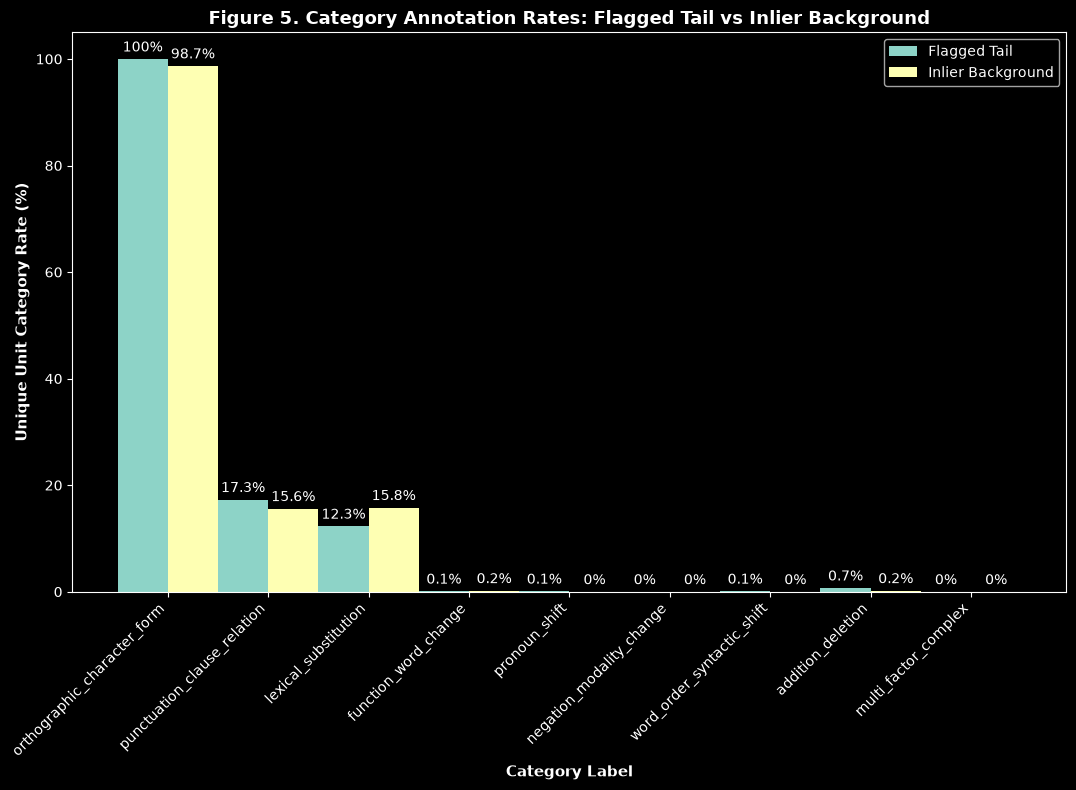

In [44]:
labels = list(dict_plot.keys())
values = list(dict_plot.values())

series_flagged = [v[0] for v in values]
series_background = [v[1] for v in values]

# positions and spacing
x_indices = np.arange(len(labels))
bar_width = 0.5

fig, ax = plt.subplots(figsize=(11,8))

bars_1 = ax.bar(x_indices - bar_width / 2, series_flagged, width=bar_width, label="Flagged Tail") # first set of bars shifted left by half width
bars_2 = ax.bar(x_indices + bar_width / 2, series_background, width=bar_width, label="Inlier Background") # second set of bars shifted right by half width

ax.set_xlabel("Category Label", fontsize=11, fontweight="bold")
ax.set_ylabel("Unique Unit Category Rate (%)", fontsize=11, fontweight="bold")
ax.set_title("Figure 5. Category Annotation Rates: Flagged Tail vs Inlier Background", fontsize=13, fontweight="bold")

# Map text labels to center position of bar groups
ax.set_xticks(x_indices)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.legend() # add legend

# Add value labels on top of bars
ax.bar_label(bars_1, padding=3, fmt="%g%%")
ax.bar_label(bars_2, padding=3, fmt="%g%%")

plt.tight_layout()
plt.show()



End Note: The visible differences in both flagged and background rows are overwhelmingly orthographic/character form changes. 

### Enrichment / Overrepresentation Results
This section analyzes the FDR corrected P-values for each category label using R0

In [45]:
# Orthograhic and character form changes

for category in category_list:
    print(f"\n{category}:")
    res_str = ""
    res_bool = bool(enrichment_res_df["significant_fdr"].loc[enrichment_res_df["category"] == category].loc[enrichment_res_df["representation"] == "R0"].unique()[0])

    # Check bool
    if res_bool:
        res_str += f"FDR Corrected P-value significant overrepresentation: FLAGGED {dict_plot[category][0]}%, INLIER_BACKGROUND {dict_plot[category][1]}%"
    else:
        res_str += f"Not significantly overrepresented: FLAGGED {dict_plot[category][0]}%, INLIER_BACKGROUND {dict_plot[category][1]}%"

    print(res_str)
    


orthographic_character_form:
FDR Corrected P-value significant overrepresentation: FLAGGED 100.0%, INLIER_BACKGROUND 98.7%

punctuation_clause_relation:
Not significantly overrepresented: FLAGGED 17.3%, INLIER_BACKGROUND 15.6%

lexical_substitution:
Not significantly overrepresented: FLAGGED 12.3%, INLIER_BACKGROUND 15.8%

function_word_change:
Not significantly overrepresented: FLAGGED 0.1%, INLIER_BACKGROUND 0.2%

pronoun_shift:
Not significantly overrepresented: FLAGGED 0.1%, INLIER_BACKGROUND 0.0%

negation_modality_change:
Not significantly overrepresented: FLAGGED 0.0%, INLIER_BACKGROUND 0.0%

word_order_syntactic_shift:
Not significantly overrepresented: FLAGGED 0.1%, INLIER_BACKGROUND 0.0%

addition_deletion:
Not significantly overrepresented: FLAGGED 0.7%, INLIER_BACKGROUND 0.2%

multi_factor_complex:
Not significantly overrepresented: FLAGGED 0.0%, INLIER_BACKGROUND 0.0%


In [46]:
print("Noteable Category Labels (rate > 5%):\n----------------------------------")
for category in category_list:
    if any(rate > 5.0 for rate in dict_plot[category]):
        print(category)

Noteable Category Labels (rate > 5%):
----------------------------------
orthographic_character_form
punctuation_clause_relation
lexical_substitution


End Note:

The strongest inferential result is orthographic_character_form as it is the only category significantly overrepresented among flagged units after FDR correction. However, the interpretation needs to note the difference is small between flagged and background units (100% vs 98.7% respectively). This finding can be described as ubiquitous with a slight overrepresentation as this category alone does not explain outliers.

punctuation_clause_relation and lexical_substitution are meaningful descriptively, but not enriched inferentially. Changes due to these categories are common enough to justify retaining the categories, but they were not disproportionately concentrated among flagged units relative to the inlier background. These types of changes occured accross the corpus, not only in the semantic drift tail.

### Explore top 10 Outliers using R0

In [47]:
top_10 = top_outliers_df.nlargest(10, "drift_r0")

for row in top_10.itertuples():
    print(f"{row.unit_key}\n----------------------")
    print(f"Drift: {row.drift_r0}")
    print(f"Categories: {annotation_df["category_labels"].loc[annotation_df["unit_key"] == row.unit_key].loc[annotation_df["representation"] == "R0"].values[0].replace("|", ", ")}")
    print(f"Character level Changes: {row.character_diff_summary.split(";",1)[1].strip().replace("examples=","")}")
    print(f"Word level Changes: {row.token_diff_summary.split(";",1)[1].strip().replace("examples=","")}")
    print(f"Phrase level Changes: {row.phrase_diff_summary.split(";",1)[1].strip().replace("examples=","")}")

    print("\n")

MRK:14:17
----------------------
Drift: 0.5350452401879036
Categories: orthographic_character_form
Character level Changes: replace: [u] -> [v] | delete: [e] -> [] | delete: [m] -> [] | replace: [u] -> [v]
Word level Changes: replace: [euening hee commeth] -> [evening he cometh] | replace: [twelue.] -> [twelve.]
Phrase level Changes: replace: [And in the euening hee commeth with the twelue] -> [And in the evening he cometh with the twelve]


1TH:5:16
----------------------
Drift: 0.5123821549303869
Categories: orthographic_character_form
Character level Changes: insert: [] -> [j o] | delete: [o y] -> [] | replace: [u] -> [v] | replace: [:] -> [.]
Word level Changes: replace: [Reioyce euermore:] -> [Rejoice evermore.]
Phrase level Changes: replace: [Reioyce euermore] -> [Rejoice evermore]


LEV:11:15
----------------------
Drift: 0.5034481012215494
Categories: orthographic_character_form, punctuation_clause_relation
Character level Changes: replace: [u] -> [v] | replace: [R] -> [r] | re

These top 10 will be good examples for the H2 and H3 discussion because they show the human readable change types behind high distance unit pair rows.

### Section Conclusion

H3 will be summarized as partially supported and clarified. HITL catrgory enrichment/overrepresentation analysis showed that flagged units were overwhelmingly characterized by orthographic and character form modernization. orthographic_character_form was the only category significantly overrepresented after FDR correction. punctuation_clause_relation and lexical_substitution categories were descriptively common but not significantly overrepresented relatvie to the inlier background set. This suggests that the observed drift tail is strongly associated with form level modernization, while more syntatically or semantically substantive categories are present but comparatively rare in this edition pair study. These findings are useful for future work using a more aggressive orthographic normalization study as these types of changes dominate the annotated drift behavior.